In [3]:


import pandas as pd
import wandb
import seaborn as sns
from soph.utils.config_generator import flatten
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=2.5, rc={"lines.linewidth": 2.5})



/home/marc_f/anaconda3/envs/soph/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def get_runs(project, filters=None, samples=500):
    """Fetch runs from wandb and return a DataFrame with history and varying config columns."""
    api = wandb.Api()
    runs = api.runs(project, filters=filters or {}, order="-created_at")
    rows = []
    for run in runs:
        config = flatten({k: v for k, v in run.config.items() if not k.startswith("_")})
        hist = pd.DataFrame(run.history(samples=samples))
        rows.append({**config, 'history': hist})
    df = pd.DataFrame(rows)
    # Keep only columns that vary across runs (plus history)
    fixed_cols = [c for c in df.columns if c != 'history' and df[c].apply(str).nunique() <= 1]
    df = df.drop(columns=fixed_cols)
    return df

In [5]:
# assembling from a few runs of different sizes, you should be able to skip this
# (the large state sizes need more hyperparameter tuning to fit the data well,
#  even in the fwd direction)
runs1 = get_runs("mfinzi/soi",{"config.tag": 'eca30_multiple_sizes3'})
runs1 = runs1[runs1['meta/reversed'] == True]
runs2 = get_runs("mfinzi/soi",{'config.tag':'eca30_multiple_sizes4'})
runs2['meta/reversed'] = False
runs3 = get_runs("mfinzi/soi",{'config.tag':'eca30_multiple_sizes5'})
runs = pd.concat([runs1, runs2,runs3], ignore_index=True)

# runs = get_runs("mfinzi/soi", {'config.tag':'eca30_multiple_sizes'}

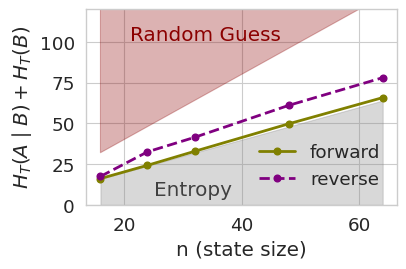

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.5)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1) compute final_bits per run
runs_df = runs.copy()
runs_df['final_bits'] = runs_df.apply(
    lambda r: r['history']['train_loss'].min() / np.log(2),
    axis=1
)

# 2) aggregate: for each (reversed, width), keep the MINIMUM final_bits
summary_df = (
    runs_df
    .groupby(['meta/reversed', 'meta/width'], as_index=False)
    .agg(final_bits=('final_bits', 'min'))
)

# 3) plot
fig, ax = plt.subplots(figsize=(4.3, 3))
palette = ["#808000", "#800080"]
widths = np.sort(summary_df['meta/width'].unique()).astype(int)

# same shading extents, no legend entries
ax.fill_between(widths, 0, widths, color='gray', alpha=0.3)
ax.fill_between(widths, 2 * widths, 1000, color='darkred', alpha=0.3)

for rev, style, label, color in [
    (False, '-', 'forward',  palette[0]),
    (True,  '--', 'reverse',  palette[1])
]:
    df = (
        summary_df[summary_df['meta/reversed'] == rev]
        .sort_values('meta/width')
    )
    ax.plot(
        df['meta/width'],
        df['final_bits'] * df['meta/width'] * 2,
        style, marker='o', color=color, label=label,lw=2
    )

# annotate and finish
ax.text(
    widths.mean()-3, (2 * widths.mean()) + 25,
    'Random Guess',
    ha='center', va='bottom', color='darkred'
)

ax.text(
    widths.mean()-5, (2 * widths.mean()) - 70,
    'Entropy',
    ha='center', va='bottom', color='black',alpha=0.7
)

ax.set(
    xlabel='n (state size)',
    ylabel=r'$H_T(A\mid B)+H_T(B)$',
    ylim=(0, 120)
)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig('figs/owf_scaling.pdf')
plt.show()